# Análise de Clientes: Pareto e Segmentação de Elite (Questão 5)

Este documento apresenta uma análise profunda da base de clientes da LH Nautical, focando em dois pilares estratégicos: a identificação do risco de concentração de receita e o mapeamento dos clientes de "Elite" para replicação de comportamento de compra.

---

### Configuração do Ambiente e Ingestão de Dados

In [2]:
import pandas as pd
import duckdb
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.data_loader import load_datasets
from src.services.bcb_api import fetch_exchange_rates

dfs = load_datasets(["vendas_2023_2024.csv", "clientes_crm.json"], layer="raw")
dfs.update(load_datasets(["produtos_processed.csv", "custos_importacao_processed.csv"]))

df_sales = dfs["vendas_2023_2024.csv"]
df_clients = dfs["clientes_crm.json"]
df_products = dfs["produtos_processed.csv"]
df_costs = dfs["custos_importacao_processed.csv"]

df_sales["sale_date"] = pd.to_datetime(df_sales["sale_date"], format="mixed", dayfirst=True).dt.date
df_costs["start_date"] = pd.to_datetime(df_costs["start_date"], format="mixed", dayfirst=True).dt.date

df_rates = fetch_exchange_rates("01-01-2022", "12-31-2024")

if df_rates.empty:
    raise ValueError("ERRO CRÍTICO: df_rates está vazio. A API do Banco Central falhou.")

df_rates["rate_date"] = pd.to_datetime(df_rates["rate_date"]).dt.date
df_rates["usd_rate"] = df_rates["usd_rate"].astype(str).str.replace(',', '.').astype(float)

### Mapeamento de Clientes de Elite (Fidelidade e Diversidade)

Seguindo as premissas da diretoria, isolamos o "Top 10" de clientes fiéis. Diferente de compradores esporádicos, este grupo é definido por um ticket médio elevado e, obrigatoriamente, ter adquirido de pelo menos três categorias distintas.


QUESTÃO 5.2 - Validação 

>> A categoria mais vendida foi a PROPULSÃO, com um total absoluto de 6030 itens comprados.

---------------------------------------------------------------------------
RESUMO DO INDICADOR:
Este volume reflete exclusivamente o padrão de consumo do grupo restrito
de 10 clientes classificados como 'Elite' (carteira filtrada pelo maior
Ticket Médio histórico e com diversidade de navegação igual ou superior
a 3 categorias distintas).



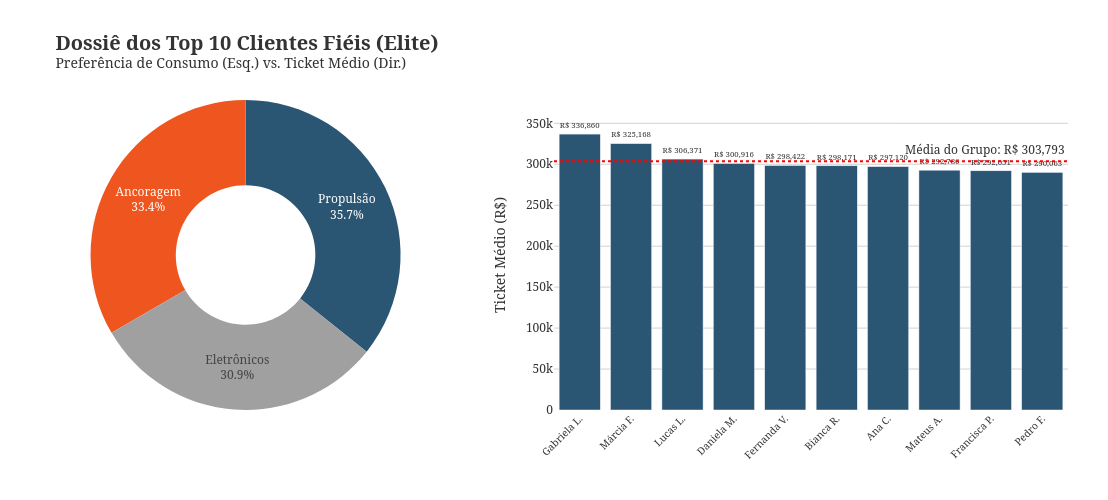

In [3]:
# ==========================================
# DATA PROCESSING
# ==========================================

query_categories = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_products: Represents produtos_raw.csv (Camada Bronze).

WITH DeduplicatedProducts AS (
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%ele%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%anc%' 
              OR LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%enc%' THEN 'ancoragem'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%prop%' THEN 'propulsão'
            ELSE 'outros' 
        END AS standardized_category,
        ROW_NUMBER() OVER(PARTITION BY code ORDER BY name) AS row_num
    FROM df_products
),
CleanProducts AS (
    SELECT product_id, standardized_category
    FROM DeduplicatedProducts
    WHERE row_num = 1
),
base_data AS (
    SELECT 
        s.id_client, 
        s.id as sell_id, 
        s.total, 
        s.qtd,
        p.standardized_category AS actual_category
    FROM df_sales s
    INNER JOIN CleanProducts p ON s.id_product = p.product_id
),
customer_metrics AS (
    SELECT id_client,
           SUM(total) / NULLIF(COUNT(DISTINCT sell_id), 0) AS average_ticket,
           COUNT(DISTINCT actual_category) AS category_diversity
    FROM base_data
    GROUP BY id_client
),
top_10_elite AS (
    SELECT id_client
    FROM customer_metrics
    WHERE category_diversity >= 3
    -- Desempate pelo id_cliente conforme regra do desafio
    ORDER BY average_ticket DESC, id_client ASC 
    LIMIT 10
)
SELECT b.actual_category, SUM(b.qtd) AS total_items_sold
FROM base_data b
INNER JOIN top_10_elite t ON b.id_client = t.id_client
GROUP BY b.actual_category
ORDER BY total_items_sold DESC;
"""

query_tickets = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_products: Represents produtos_raw.csv.
-- df_clients: Represents clientes_crm.json.

WITH DeduplicatedProducts AS (
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%ele%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%anc%' 
              OR LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%enc%' THEN 'ancoragem'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%prop%' THEN 'propulsão'
            ELSE 'outros' 
        END AS standardized_category,
        ROW_NUMBER() OVER(PARTITION BY code ORDER BY name) AS row_num
    FROM df_products
),
CleanProducts AS (
    SELECT product_id, standardized_category
    FROM DeduplicatedProducts
    WHERE row_num = 1
),
base_data AS (
    SELECT s.id_client, s.id as sell_id, s.total, p.standardized_category AS actual_category
    FROM df_sales s
    INNER JOIN CleanProducts p ON s.id_product = p.product_id
),
customer_metrics AS (
    SELECT 
        c.full_name AS raw_client_name,
        b.id_client,
        SUM(b.total) / NULLIF(COUNT(DISTINCT b.sell_id), 0) AS average_ticket,
        COUNT(DISTINCT b.actual_category) AS category_diversity
    FROM base_data b
    INNER JOIN df_clients c ON b.id_client = c.code
    GROUP BY c.full_name, b.id_client
)
SELECT raw_client_name, average_ticket
FROM customer_metrics
WHERE category_diversity >= 3
-- Desempate pelo id_cliente ascendente garantido
ORDER BY average_ticket DESC, id_client ASC
LIMIT 10;
"""

df_categories = duckdb.query(query_categories).df()
df_tickets = duckdb.query(query_tickets).df()

if not df_categories.empty:
    top_category = df_categories.iloc[0]
    
    # Extrai as variáveis dinamicamente
    category_name = str(top_category['actual_category']).upper()
    total_items = int(top_category['total_items_sold'])

    print("\n" + "="*75)
    print("QUESTÃO 5.2 - Validação ")
    print("="*75 + "\n")
    
    print(f">> A categoria mais vendida foi a {category_name}, "
          f"com um total absoluto de {total_items} itens comprados.\n")
    
    print("-" * 75)
    print("RESUMO DO INDICADOR:")
    print("Este volume reflete exclusivamente o padrão de consumo do grupo restrito")
    print("de 10 clientes classificados como 'Elite' (carteira filtrada pelo maior")
    print("Ticket Médio histórico e com diversidade de produtos adquiridos igual ou superior")
    print("a 3 categorias distintas).")
    print("="*75 + "\n")
# ==========================================
# VISUALIZATION
# ==========================================

if not df_categories.empty and not df_tickets.empty:
    
    # --- Transformação de Apresentação (Nome Enxuto) ---
    def format_short_name(full_name):
        parts = str(full_name).strip().split()
        if len(parts) > 1:
            # Retorna o Primeiro Nome + A primeira letra do último sobrenome com ponto
            return f"{parts[0]} {parts[-1][0]}." 
        return full_name

    # Aplica a regra para criar a coluna que irá para o gráfico
    df_tickets['client_name'] = df_tickets['raw_client_name'].apply(format_short_name)

    
    fig = go.Figure()

    fig.add_trace(go.Pie(
        labels=df_categories['actual_category'].str.title(),
        values=df_categories['total_items_sold'],
        hole=.45,
        domain=dict(x=[0, 0.4]),
        marker_colors=['rgb(42, 86, 116)', 'rgb(239, 85, 30)', 'rgb(160, 160, 160)'],
        hovertemplate="<b>%{label}</b><br>Itens: %{value}<br>Fatia: %{percent}<extra></extra>",
        textinfo='label+percent',
        textposition='inside'
    ))

    fig.add_trace(go.Bar(
        x=df_tickets['client_name'], 
        y=df_tickets['average_ticket'],
        marker_color='rgb(42, 86, 116)',
        text=df_tickets['average_ticket'],
        texttemplate='R$ %{text:,.0f}',
        textposition='outside',
        hovertemplate="<b>%{customdata}</b><br>Ticket Médio: R$ %{y:,.2f}<extra></extra>",
        customdata=df_tickets['raw_client_name'],
        xaxis='x',
        yaxis='y'
    ))

    media_grupo = df_tickets['average_ticket'].mean()

    fig.update_layout(
        title_text="<b>Dossiê dos Top 10 Clientes Fiéis (Elite)</b><br><sup>Preferência de Consumo (Esq.) vs. Ticket Médio (Dir.)</sup>",
        title_font=dict(size=20, color="#333333"),
        font=dict(family="Arial", size=12, color="#333333"),
        plot_bgcolor="white",
        showlegend=False,
        margin=dict(t=100, b=40, l=40, r=40),
        height=500,
        
        xaxis=dict(
            domain=[0.5, 1.0], 
            title="", 
            tickangle=-45, 
            showgrid=False,
            tickfont=dict(size=10)
        ),
        
        yaxis=dict(title="Ticket Médio (R$)", showgrid=True, gridcolor='lightgrey')
    )

    fig.add_hline(y=media_grupo, line_dash="dot", line_color="red", 
                  annotation_text=f"Média do Grupo: R$ {media_grupo:,.0f}", 
                  annotation_position="top right")

    fig.show()

else:
    print("Nenhum cliente atendeu aos critérios de Elite definidos.")

### Análise de Pareto: Concentração de Receita

Abaixo, aplicamos a Regra de 80/20. O objetivo é validar se uma pequena parcela da base de clientes é responsável pela grande maioria do faturamento.

=== RISCO DE CONCENTRAÇÃO ===
O faturamento total vem de uma base de 49 clientes.
No entanto, 80% de toda a receita da empresa está concentrada em apenas 36 clientes (73.5% da base).
SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.



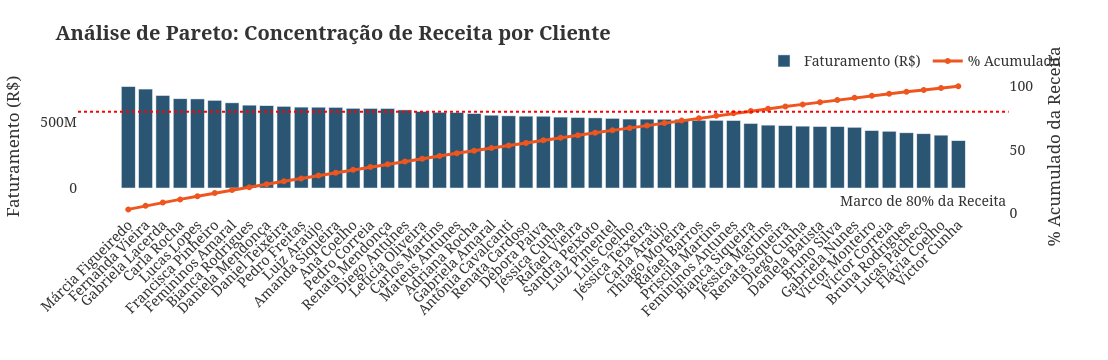

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import duckdb
import pandas as pd

query_pareto = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_clients: Represents clientes_crm.json.

WITH client_revenue AS (
    SELECT
        id_client,
        SUM(total * qtd) AS total_revenue
    FROM df_sales
    GROUP BY id_client
),
ranked_revenue AS (
    SELECT
        c.full_name AS raw_client_name, -- Puxa o nome completo bruto
        cr.total_revenue,
        SUM(cr.total_revenue) OVER (ORDER BY cr.total_revenue DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_revenue,
        SUM(cr.total_revenue) OVER () AS grand_total
    FROM client_revenue cr
    INNER JOIN df_clients c 
        ON cr.id_client = c.code
)
SELECT
    raw_client_name,
    total_revenue,
    (cumulative_revenue / grand_total) * 100 AS cumulative_percentage
FROM ranked_revenue
ORDER BY total_revenue DESC;
"""


df_pareto = duckdb.query(query_pareto).df()


def format_professional_name(full_name):
    parts = str(full_name).strip().split()
    
    if len(parts) > 1:
        return f"{parts[0]} {parts[-1]}"
 
    return full_name

df_pareto['client_name'] = df_pareto['raw_client_name'].apply(format_professional_name)

total_clientes = len(df_pareto)
clientes_80_porcento = len(df_pareto[df_pareto['cumulative_percentage'] <= 80])
concentracao = (clientes_80_porcento / total_clientes) * 100

print("=== RISCO DE CONCENTRAÇÃO ===")
print(f"O faturamento total vem de uma base de {total_clientes} clientes.")
print(f"No entanto, 80% de toda a receita da empresa está concentrada em apenas {clientes_80_porcento} clientes ({concentracao:.1f}% da base).")

if concentracao <= 20:
    print("ALERTA DE RISCO ALTO: A regra de Pareto (80/20) é muito forte aqui. A perda de um top cliente causará grande impacto.")
else:
    print("SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.")

print("===========================================================\n")

# --- Visualização (Plotly) ---
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_pareto['client_name'],
        y=df_pareto['total_revenue'],
        name="Faturamento (R$)",
        marker_color='rgb(42, 86, 116)',
        hovertemplate="Faturamento: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_pareto['client_name'],
        y=df_pareto['cumulative_percentage'],
        name="% Acumulado",
        mode='lines+markers',
        line=dict(color='rgb(239, 85, 30)', width=3),
        marker=dict(size=6),
        hovertemplate="Acumulado: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title="<b>Análise de Pareto: Concentração de Receita por Cliente</b>",
    plot_bgcolor="white",
    font=dict(family="Arial", size=14, color="#333333"),
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(title_text="", showgrid=False, tickangle=-45)
fig.update_yaxes(title_text="Faturamento (R$)", showgrid=False, secondary_y=False)
fig.update_yaxes(title_text="% Acumulado da Receita", range=[0, 105], showgrid=False, secondary_y=True)

fig.add_hline(y=80, line_dash="dot", line_color="red", secondary_y=True, 
              annotation_text="Marco de 80% da Receita", annotation_position="bottom right")

fig.show()

### Questão 5.3 - Interpretação

**Como foi realizada a limpeza das categorias?**

Através do script de normalização construído na etapa de ETL (questão 02) para consolidar variações de grafia e erros de digitação e assim garantir que a métrica de "diversidade de categorias" não fosse inflada artificialmente por registros duplicados.

**Lógica de Filtro e Isolamento:**

A garantia de que a contagem de itens reflete apenas os Top 10 foi assegurada por um `INNER JOIN` entre a tabela de fatos e a CTE de ranking, isolando o comportamento de compra deste grupo específico antes de qualquer agregação final.

**Como você realizou a limpeza das categorias?**

A limpeza foi feita diretamente via SQL na ingestão dos dados. Padronizei as strings removendo espaços com REPLACE() e convertendo para minúsculo com LOWER(). Em seguida, apliquei a instrução CASE WHEN com o operador LIKE para buscar raízes textuais livres de acentos, ex: '%anc%' e '%enc%' mapeados para "ancoragem". Garanti que cada produto fosse único usando a função de janela ROW_NUMBER() = 1, o que evitou distorções de volume nas junções.

**Qual lógica utilizou para filtrar os clientes com diversidade mínima?**

Primeiro, criei uma CTE transacional (base_data) que cruzou as vendas com o cadastro já limpo de produtos. Na etapa de agregação, contei a quantidade de categorias únicas acessadas por cada cliente utilizando COUNT(DISTINCT actual_category). O filtro final foi aplicado por meio de um WHERE category_diversity >= 3, seguido por uma ordenação descendente do ticket médio limitando aos 10 primeiros registros (Top 10).

**Como garantiu que a contagem de itens refletisse apenas os Top 10?**

Isolei os IDs dos 10 clientes de elite em uma CTE auxiliar chamada top_10_elite. Na query final, realizei um INNER JOIN entre o histórico total de transações (base_data) e esta CTE. Por conta do comportamento estrito do INNER JOIN, a tabela resultante excluiu todas as transações que não pertenciam aos clientes da lista de elite, permitindo a soma limpa da quantidade (SUM(qtd)) agrupada por categoria.